# DonorsChoose

<p>
DonorsChoose.org receives hundreds of thousands of project proposals each year for classroom projects in need of funding. Right now, a large number of volunteers is needed to manually screen each submission before it's approved to be posted on the DonorsChoose.org website.
</p>
<p>
    Next year, DonorsChoose.org expects to receive close to 500,000 project proposals. As a result, there are three main problems they need to solve:
<ul>
<li>
    How to scale current manual processes and resources to screen 500,000 projects so that they can be posted as quickly and as efficiently as possible</li>
    <li>How to increase the consistency of project vetting across different volunteers to improve the experience for teachers</li>
    <li>How to focus volunteer time on the applications that need the most assistance</li>
    </ul>
</p>    
<p>
The goal of the competition is to predict whether or not a DonorsChoose.org project proposal submitted by a teacher will be approved, using the text of project descriptions as well as additional metadata about the project, teacher, and school. DonorsChoose.org can then use this information to identify projects most likely to need further review before approval.
</p>

## About the DonorsChoose Data Set

The `train.csv` data set provided by DonorsChoose contains the following features:

Feature | Description 
----------|---------------
**`project_id`** | A unique identifier for the proposed project. **Example:** `p036502`   
**`project_title`**    | Title of the project. **Examples:**<br><ul><li><code>Art Will Make You Happy!</code></li><li><code>First Grade Fun</code></li></ul> 
**`project_grade_category`** | Grade level of students for which the project is targeted. One of the following enumerated values: <br/><ul><li><code>Grades PreK-2</code></li><li><code>Grades 3-5</code></li><li><code>Grades 6-8</code></li><li><code>Grades 9-12</code></li></ul>  
 **`project_subject_categories`** | One or more (comma-separated) subject categories for the project from the following enumerated list of values:  <br/><ul><li><code>Applied Learning</code></li><li><code>Care &amp; Hunger</code></li><li><code>Health &amp; Sports</code></li><li><code>History &amp; Civics</code></li><li><code>Literacy &amp; Language</code></li><li><code>Math &amp; Science</code></li><li><code>Music &amp; The Arts</code></li><li><code>Special Needs</code></li><li><code>Warmth</code></li></ul><br/> **Examples:** <br/><ul><li><code>Music &amp; The Arts</code></li><li><code>Literacy &amp; Language, Math &amp; Science</code></li>  
  **`school_state`** | State where school is located ([Two-letter U.S. postal code](https://en.wikipedia.org/wiki/List_of_U.S._state_abbreviations#Postal_codes)). **Example:** `WY`
**`project_subject_subcategories`** | One or more (comma-separated) subject subcategories for the project. **Examples:** <br/><ul><li><code>Literacy</code></li><li><code>Literature &amp; Writing, Social Sciences</code></li></ul> 
**`project_resource_summary`** | An explanation of the resources needed for the project. **Example:** <br/><ul><li><code>My students need hands on literacy materials to manage sensory needs!</code</li></ul> 
**`project_essay_1`**    | First application essay<sup>*</sup>  
**`project_essay_2`**    | Second application essay<sup>*</sup> 
**`project_essay_3`**    | Third application essay<sup>*</sup> 
**`project_essay_4`**    | Fourth application essay<sup>*</sup> 
**`project_submitted_datetime`** | Datetime when project application was submitted. **Example:** `2016-04-28 12:43:56.245`   
**`teacher_id`** | A unique identifier for the teacher of the proposed project. **Example:** `bdf8baa8fedef6bfeec7ae4ff1c15c56`  
**`teacher_prefix`** | Teacher's title. One of the following enumerated values: <br/><ul><li><code>nan</code></li><li><code>Dr.</code></li><li><code>Mr.</code></li><li><code>Mrs.</code></li><li><code>Ms.</code></li><li><code>Teacher.</code></li></ul>  
**`teacher_number_of_previously_posted_projects`** | Number of project applications previously submitted by the same teacher. **Example:** `2` 

<sup>*</sup> See the section <b>Notes on the Essay Data</b> for more details about these features.

Additionally, the `resources.csv` data set provides more data about the resources required for each project. Each line in this file represents a resource required by a project:

Feature | Description 
----------|---------------
**`id`** | A `project_id` value from the `train.csv` file.  **Example:** `p036502`   
**`description`** | Desciption of the resource. **Example:** `Tenor Saxophone Reeds, Box of 25`   
**`quantity`** | Quantity of the resource required. **Example:** `3`   
**`price`** | Price of the resource required. **Example:** `9.95`   

**Note:** Many projects require multiple resources. The `id` value corresponds to a `project_id` in train.csv, so you use it as a key to retrieve all resources needed for a project:

The data set contains the following label (the value you will attempt to predict):

Label | Description
----------|---------------
`project_is_approved` | A binary flag indicating whether DonorsChoose approved the project. A value of `0` indicates the project was not approved, and a value of `1` indicates the project was approved.

### Notes on the Essay Data

<ul>
Prior to May 17, 2016, the prompts for the essays were as follows:
<li>__project_essay_1:__ "Introduce us to your classroom"</li>
<li>__project_essay_2:__ "Tell us more about your students"</li>
<li>__project_essay_3:__ "Describe how your students will use the materials you're requesting"</li>
<li>__project_essay_3:__ "Close by sharing why your project will make a difference"</li>
</ul>


<ul>
Starting on May 17, 2016, the number of essays was reduced from 4 to 2, and the prompts for the first 2 essays were changed to the following:<br>
<li>__project_essay_1:__ "Describe your students: What makes your students special? Specific details about their background, your neighborhood, and your school are all helpful."</li>
<li>__project_essay_2:__ "About your project: How will these materials make a difference in your students' learning and improve their school lives?"</li>
<br>For all projects with project_submitted_datetime of 2016-05-17 and later, the values of project_essay_3 and project_essay_4 will be NaN.
</ul>


In [1]:
    %matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import pandas as pd
import numpy as np
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from nltk.stem.porter import PorterStemmer
from sklearn.linear_model import LogisticRegression
import re
# Tutorial about Python regular expressions: https://pymotw.com/2/re/
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer

from gensim.models import Word2Vec
from gensim.models import KeyedVectors
import pickle

from tqdm import tqdm
import os

from chart_studio.plotly import iplot
import plotly.offline as offline
import plotly.graph_objs as go
offline.init_notebook_mode()
from collections import Counter

## 1.1 Reading Data

In [2]:
project_data = pd.read_csv('train_data.csv')
resource_data = pd.read_csv('resources.csv')

In [3]:
print("Number of data points in train data", project_data.shape)
print('-'*50)
print("The attributes of data :", project_data.columns.values)

Number of data points in train data (109248, 17)
--------------------------------------------------
The attributes of data : ['Unnamed: 0' 'id' 'teacher_id' 'teacher_prefix' 'school_state'
 'project_submitted_datetime' 'project_grade_category'
 'project_subject_categories' 'project_subject_subcategories'
 'project_title' 'project_essay_1' 'project_essay_2' 'project_essay_3'
 'project_essay_4' 'project_resource_summary'
 'teacher_number_of_previously_posted_projects' 'project_is_approved']


In [4]:
#Removing all hte rows where teacher prefix is NAN
project_data =  project_data.dropna(axis='index',subset=['teacher_prefix'])

In [5]:
# how to replace elements in list python: https://stackoverflow.com/a/2582163/4084039
cols = ['Date' if x=='project_submitted_datetime' else x for x in list(project_data.columns)]


#sort dataframe based on time pandas python: https://stackoverflow.com/a/49702492/4084039
project_data['Date'] = pd.to_datetime(project_data['project_submitted_datetime'])
project_data.drop('project_submitted_datetime', axis=1, inplace=True)
project_data.sort_values(by=['Date'], inplace=True)


# how to reorder columns pandas python: https://stackoverflow.com/a/13148611/4084039
project_data = project_data[cols]


project_data.head(2)

,Unnamed: 0,id,teacher_id,teacher_prefix,school_state,Date,project_grade_category,project_subject_categories,project_subject_subcategories,project_title,project_essay_1,project_essay_2,project_essay_3,project_essay_4,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved
55660,8393,p205479,2bf07ba08945e5d8b2a3f269b2b3cfe5,Mrs.,CA,2016-04-27 00:27:36,Grades PreK-2,Math & Science,"Applied Sciences, Health & Life Science",Engineering STEAM into the Primary Classroom,I have been fortunate enough to use the Fairy ...,My students come from a variety of backgrounds...,Each month I try to do several science or STEM...,It is challenging to develop high quality scie...,My students need STEM kits to learn critical s...,53,1
76127,37728,p043609,3f60494c61921b3b43ab61bdde2904df,Ms.,UT,2016-04-27 00:31:25,Grades 3-5,Special Needs,Special Needs,Sensory Tools for Focus,Imagine being 8-9 years old. You're in your th...,"Most of my students have autism, anxiety, anot...",It is tough to do more than one thing at a tim...,When my students are able to calm themselves d...,My students need Boogie Boards for quiet senso...,4,1


In [6]:
print("Number of data points in train data", resource_data.shape)
print(resource_data.columns.values)
resource_data.head(2)

Number of data points in train data (1541272, 4)
['id' 'description' 'quantity' 'price']


,id,description,quantity,price
0,p233245,LC652 - Lakeshore Double-Space Mobile Drying Rack,1,149.00
1,p069063,Bouncy Bands for Desks (Blue support pipes),3,14.95


In [7]:
##  Counting the total Number of 0 and 1
project_data['project_is_approved'].value_counts()

1    92703
0    16542
Name: project_is_approved, dtype: int64

## 1.2 preprocessing of `project_subject_categories`

In [8]:
catogories = list(project_data['project_subject_categories'].values)
# remove special characters from list of strings python: https://stackoverflow.com/a/47301924/4084039

# https://www.geeksforgeeks.org/removing-stop-words-nltk-python/
# https://stackoverflow.com/questions/23669024/how-to-strip-a-specific-word-from-a-string
# https://stackoverflow.com/questions/8270092/remove-all-whitespace-in-a-string-in-python
cat_list = []
for i in catogories:
    temp = ""
    # consider we have text like this "Math & Science, Warmth, Care & Hunger"
    for j in i.split(','): # it will split it in three parts ["Math & Science", "Warmth", "Care & Hunger"]
        if 'The' in j.split(): # this will split each of the catogory based on space "Math & Science"=> "Math","&", "Science"
            j=j.replace('The','') # if we have the words "The" we are going to replace it with ''(i.e removing 'The')
        j = j.replace(' ','') # we are placeing all the ' '(space) with ''(empty) ex:"Math & Science"=>"Math&Science"
        temp+=j.strip()+" " #" abc ".strip() will return "abc", remove the trailing spaces
        temp = temp.replace('&','_') # we are replacing the & value into 
    cat_list.append(temp.strip())
    
project_data['clean_categories'] = cat_list
project_data.drop(['project_subject_categories'], axis=1, inplace=True)

from collections import Counter
my_counter = Counter()
for word in project_data['clean_categories'].values:
    my_counter.update(word.split())

cat_dict = dict(my_counter)
sorted_cat_dict = dict(sorted(cat_dict.items(), key=lambda kv: kv[1]))


## 1.2 preprocessing of `project_subject_subcategories``m

In [9]:
sub_catogories = list(project_data['project_subject_subcategories'].values)
# remove special characters from list of strings python: https://stackoverflow.com/a/47301924/4084039

# https://www.geeksforgeeks.org/removing-stop-words-nltk-python/
# https://stackoverflow.com/questions/23669024/how-to-strip-a-specific-word-from-a-string
# https://stackoverflow.com/questions/8270092/remove-all-whitespace-in-a-string-in-python

sub_cat_list = []
for i in sub_catogories:
    temp = ""
    # consider we have text like this "Math & Science, Warmth, Care & Hunger"
    for j in i.split(','): # it will split it in three parts ["Math & Science", "Warmth", "Care & Hunger"]
        if 'The' in j.split(): # this will split each of the catogory based on space "Math & Science"=> "Math","&", "Science"
            j=j.replace('The','') # if we have the words "The" we are going to replace it with ''(i.e removing 'The')
        j = j.replace(' ','') # we are placeing all the ' '(space) with ''(empty) ex:"Math & Science"=>"Math&Science"
        temp +=j.strip()+" "#" abc ".strip() will return "abc", remove the trailing spaces
        temp = temp.replace('&','_')
    sub_cat_list.append(temp.strip())

project_data['clean_subcategories'] = sub_cat_list
project_data.drop(['project_subject_subcategories'], axis=1, inplace=True)

# count of all the words in corpus python: https://stackoverflow.com/a/22898595/4084039
my_counter = Counter()
for word in project_data['clean_subcategories'].values:
    my_counter.update(word.split())
    
sub_cat_dict = dict(my_counter)
sorted_sub_cat_dict = dict(sorted(sub_cat_dict.items(), key=lambda kv: kv[1]))

## 1.2 preprocessing of `project_grade_category`

In [10]:
grade_catogories = list(project_data['project_grade_category'].values)
# remove special characters from list of strings python: https://stackoverflow.com/a/47301924/4084039

# https://www.geeksforgeeks.org/removing-stop-words-nltk-python/
# https://stackoverflow.com/questions/23669024/how-to-strip-a-specific-word-from-a-string
# https://stackoverflow.com/questions/8270092/remove-all-whitespace-in-a-string-in-python

grade_cat_list = []
for i in grade_catogories:
    temp = ""
    temp = i.replace(' ','') 
    temp = temp.replace('-','_')
    grade_cat_list.append(temp.strip())
grade_cat_list
project_data['grade_categories'] = grade_cat_list
# project_data.drop(['project_grade_category'], axis=1, inplace=True)

## 1.3 Text preprocessing

In [11]:
# merge two column text dataframe: 
project_data["essay"] = project_data["project_essay_1"].map(str) +\
                        project_data["project_essay_2"].map(str) + \
                        project_data["project_essay_3"].map(str) + \
                        project_data["project_essay_4"].map(str)

In [12]:
# printing some random reviews
print(project_data['essay'].values[0])
print("="*50)
print(project_data['essay'].values[150])
print("="*50)
print(project_data['essay'].values[1000])
print("="*50)
print(project_data['essay'].values[20000])
print("="*50)
print(project_data['essay'].values[99999])
print("="*50)

I have been fortunate enough to use the Fairy Tale STEM kits in my classroom as well as the STEM journals, which my students really enjoyed.  I would love to implement more of the Lakeshore STEM kits in my classroom for the next school year as they provide excellent and engaging STEM lessons.My students come from a variety of backgrounds, including language and socioeconomic status.  Many of them don't have a lot of experience in science and engineering and these kits give me the materials to provide these exciting opportunities for my students.Each month I try to do several science or STEM/STEAM projects.  I would use the kits and robot to help guide my science instruction in engaging and meaningful ways.  I can adapt the kits to my current language arts pacing guide where we already teach some of the material in the kits like tall tales (Paul Bunyan) or Johnny Appleseed.  The following units will be taught in the next school year where I will implement these kits: magnets, motion, si

In [13]:
# https://stackoverflow.com/a/47091490/4084039
import re

def decontracted(phrase):
    # specific
    phrase = re.sub(r"won't", "will not", phrase)
    phrase = re.sub(r"can\'t", "can not", phrase)

    # general
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"\'s", " is", phrase)
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)
    return phrase

In [14]:
sent = decontracted(project_data['essay'].values[20000])
print(sent)
print("="*50)

Some of my students come from difficult family lives, but they do not let that stop them. We have built a community in our classroom that allows each student to be comfortable with who they are. Even though we are a diverse school, everyone feels included. We have a high Hispanic population, and about 90% of the students are on free or reduced-price lunch. Most students are living with a single parent or both parents work full time, although many parents are eager to help in any way they can.\r\nWe all know how important it is to get kids up and moving. I want my classroom to be a place where students can be active phyically and mentally. The requested items will allow my students to move all day. When they are sitting in a chair, their movement is limited.\r\n       Kindergarten students have a hard time sitting still for long periods of time. They would much rather bounce on a stability ball or wiggle on a cushion than sit in a hard chair. Having these choices in my classroom will al

In [15]:
# \r \n \t remove from string python: http://texthandler.com/info/remove-line-breaks-python/
sent = sent.replace('\\r', ' ')
sent = sent.replace('\\"', ' ')
sent = sent.replace('\\n', ' ')
print(sent)

Some of my students come from difficult family lives, but they do not let that stop them. We have built a community in our classroom that allows each student to be comfortable with who they are. Even though we are a diverse school, everyone feels included. We have a high Hispanic population, and about 90% of the students are on free or reduced-price lunch. Most students are living with a single parent or both parents work full time, although many parents are eager to help in any way they can.  We all know how important it is to get kids up and moving. I want my classroom to be a place where students can be active phyically and mentally. The requested items will allow my students to move all day. When they are sitting in a chair, their movement is limited.         Kindergarten students have a hard time sitting still for long periods of time. They would much rather bounce on a stability ball or wiggle on a cushion than sit in a hard chair. Having these choices in my classroom will allow 

In [16]:
# https://gist.github.com/sebleier/554280
# we are removing the words from the stop words list: 'no', 'nor', 'not'
stopwords= ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've",\
            "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', \
            'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their',\
            'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', \
            'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', \
            'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', \
            'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after',\
            'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further',\
            'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',\
            'most', 'other', 'some', 'such', 'only', 'own', 'same', 'so', 'than', 'too', 'very', \
            's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', \
            've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn',\
            "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',\
            "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", \
            'won', "won't", 'wouldn', "wouldn't"]

In [17]:
# Combining all the above stundents 
from tqdm import tqdm
preprocessed_essays = []
# tqdm is for printing the status bar
for sentance in tqdm(project_data['essay'].values):
    sent = decontracted(sentance)
    sent = sent.replace('\\r', ' ')
    sent = sent.replace('\\"', ' ')
    sent = sent.replace('\\n', ' ')
    sent = re.sub('[^A-Za-z0-9]+', ' ', sent)
    # https://gist.github.com/sebleier/554280
    sent = ' '.join(e for e in sent.split() if e.lower() not in stopwords)
    preprocessed_essays.append(sent.lower().strip())

100%|████████████████████████████████████████████████████████████████████████| 109245/109245 [01:00<00:00, 1803.83it/s]


In [18]:
# after preprocesing
preprocessed_essays[20000]

'students come difficult family lives not let stop built community classroom allows student comfortable even though diverse school everyone feels included high hispanic population 90 students free reduced price lunch students living single parent parents work full time although many parents eager help way know important get kids moving want classroom place students active phyically mentally requested items allow students move day sitting chair movement limited kindergarten students hard time sitting still long periods time would much rather bounce stability ball wiggle cushion sit hard chair choices classroom allow students active learn time choices classroom also build greater bond students learn choose seat best fits learning style hopefully able help classmates find seat works students move around room able work everyone instead one group day nannan'

### 1.4 Preprocessing of `project_title    

In [19]:
# similarly you can preprocess the titles also
preprocessed_title =  []

for sentence in tqdm(project_data['project_title'].values):
    sent = decontracted(sentence)
    sent = sent.replace('\\r', ' ')
    sent = sent.replace('\\"', ' ')
    sent = sent.replace('\\n', ' ')
    sent = re.sub('[^A-Za-z0-9]+', ' ', sentence)
    sent = ' '.join(e for e in sent.split() if e not in stopwords)
    preprocessed_title.append(sent.lower().strip())

100%|███████████████████████████████████████████████████████████████████████| 109245/109245 [00:02<00:00, 39022.24it/s]


In [20]:
project_data['preprocessed_essays'] =preprocessed_essays
project_data['preprocessed_title'] = preprocessed_title

In [21]:
price_data = resource_data.groupby('id').agg({'price':'sum', 'quantity':'sum'}).reset_index()
project_data = pd.merge(project_data, price_data, on='id', how='left')

In [22]:
no_words_in_title = project_data["preprocessed_title"].astype(str).str.len() 
no_words_in_essays = project_data["preprocessed_essays"].astype(str).str.len() 

In [23]:
project_data['no_words_in_title'] = no_words_in_title
project_data['no_words_in_essays'] = no_words_in_essays

In [24]:
#Seperating Project approved column and Feature culumn of project data 
y = project_data['project_is_approved'].values
X = project_data.drop(['project_is_approved'], axis=1)
X.head(1)

,Unnamed: 0,id,teacher_id,teacher_prefix,school_state,Date,project_grade_category,project_title,project_essay_1,project_essay_2,...,clean_categories,clean_subcategories,grade_categories,essay,preprocessed_essays,preprocessed_title,price,quantity,no_words_in_title,no_words_in_essays
0,8393,p205479,2bf07ba08945e5d8b2a3f269b2b3cfe5,Mrs.,CA,2016-04-27 00:27:36,Grades PreK-2,Engineering STEAM into the Primary Classroom,I have been fortunate enough to use the Fairy ...,My students come from a variety of backgrounds...,...,Math_Science,AppliedSciences Health_LifeScience,GradesPreK_2,I have been fortunate enough to use the Fairy ...,fortunate enough use fairy tale stem kits clas...,engineering steam primary classroom,725.05,4,35,1118


# Assignment 9: RF and GBDT

#### Response Coding: Example

<img src='response.JPG' width=700px>

> The response tabel is built only on train dataset.
> For a category which is not there in train data and present in test data, we will encode them with default values
Ex: in our test data if have State: D then we encode it as [0.5, 0.5]

<ol>
    <li><strong>Apply both Random Forrest and GBDT on these feature sets</strong>
        <ul>
            <li><font color='red'>Set 1</font>: categorical(instead of one hot encoding, try <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/handling-categorical-and-numerical-features/'>response coding</a>: use probability values), numerical features + project_title(BOW) + preprocessed_eassay (BOW)</li>
            <li><font color='red'>Set 2</font>: categorical(instead of one hot encoding, try <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/handling-categorical-and-numerical-features/'>response coding</a>: use probability values), numerical features + project_title(TFIDF)+  preprocessed_eassay (TFIDF)</li>
            <li><font color='red'>Set 3</font>: categorical(instead of one hot encoding, try <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/handling-categorical-and-numerical-features/'>response coding</a>: use probability values), numerical features + project_title(AVG W2V)+  preprocessed_eassay (AVG W2V). Here for this set take <b>20K</b> datapoints only. </li>
            <li><font color='red'>Set 4</font>: categorical(instead of one hot encoding, try <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/handling-categorical-and-numerical-features/'>response coding</a>: use probability values), numerical features + project_title(TFIDF W2V)+  preprocessed_eassay (TFIDF W2V). Here for this set take <b>20K</b> datapoints only. </li>        </ul>
    </li>
    <br>
    <li><strong>The hyper paramter tuning (Consider any two hyper parameters preferably n_estimators, max_depth)</strong>
        <ul>
          <li> Consider the following range for hyperparameters <b>n_estimators</b> = [10, 50, 100, 150, 200, 300, 500, 1000], 
            <b>max_depth</b> = [2, 3, 4, 5, 6, 7, 8, 9, 10] </li>
    <li>Find the best hyper parameter which will give the maximum <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/receiver-operating-characteristic-curve-roc-curve-and-auc-1/'>AUC</a> value</li>
    <li>Find the best hyper paramter using simple cross validation data</li>
    <li>You can write your own for loops to do this task</li>
        </ul>
    </li>
    <br>
    <li>
    <strong>Representation of results</strong>
        <ul>
    <li>You need to plot the performance of model both on train data and cross validation data for each hyper parameter, like shown in the figure
    <img src='3d_plot.JPG' width=500px> with X-axis as <strong>n_estimators</strong>, Y-axis as <strong>max_depth</strong>, and Z-axis as <strong>AUC Score</strong> , we have given the notebook which explains how to plot this 3d plot, you can find it in the same drive <i>3d_scatter_plot.ipynb</i></li>
            <p style="text-align:center;font-size:30px;color:red;"><strong>or</strong></p> <br>
    <li>You need to plot the performance of model both on train data and cross validation data for each hyper parameter, like shown in the figure
    <img src='heat_map.JPG' width=300px> <a href='https://seaborn.pydata.org/generated/seaborn.heatmap.html'>seaborn heat maps</a> with rows as <strong>n_estimators</strong>, columns as <strong>max_depth</strong>, and values inside the cell representing <strong>AUC Score</strong> </li>
    <li>You can choose either of the plotting techniques: 3d plot or heat map</li>
    <li>Once after you found the best hyper parameter, you need to train your model with it, and find the AUC on test data and plot the ROC curve on both train and test.
    <img src='train_test_auc.JPG' width=300px></li>
    <li>Along with plotting ROC curve, you need to print the <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/confusion-matrix-tpr-fpr-fnr-tnr-1/'>confusion matrix</a> with predicted and original labels of test data points
    <img src='confusion_matrix.png' width=300px></li>
            </ul>
    <br>
    <li><strong>Conclusion</strong>
        <ul>
    <li>You need to summarize the results at the end of the notebook, summarize it in the table format. To print out a table please refer to this prettytable library<a href='http://zetcode.com/python/prettytable/'>  link</a> 
        <img src='summary.JPG' width=400px>
    </li>
        </ul>
</ol>

<h4><font color='red'>Note: Data Leakage</font></h4>

1. There will be an issue of data-leakage if you vectorize the entire data and then split it into train/cv/test.
2. To avoid the issue of data-leakag, make sure to split your data first and then vectorize it. 
3. While vectorizing your data, apply the method fit_transform() on you train data, and apply the method transform() on cv/test data.
4. For more details please go through this <a href='https://soundcloud.com/applied-ai-course/leakage-bow-and-tfidf'>link.</a>

<h1>2. Random Forest and GBDT </h1>

<h2>2.1 Splitting data into Train and cross validation(or test): Stratified Sampling</h2>

In [25]:
  # train test split
# To avoid the issue of data-leakag, make sure to split your data first and then vectorize it.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y)
X_train, X_cv, y_train, y_cv = train_test_split(X_train, y_train, test_size=0.33, stratify=y_train)      

### Response Coding for clean_categories

In [26]:
feature_name = list(X_train.clean_categories.unique())

In [27]:
clean_cat_prob= []
for value in tqdm(feature_name):
    sample = len(X_train[X_train['clean_categories'] == value])
    pos_list =  X_train.index[X_train['clean_categories'] == value].tolist()
    total_pos = 0
    for i in pos_list:
        if y[i] ==  1:
            total_pos +=1
    positive  = total_pos/sample
    negative  = 1-positive
    prob = [positive,negative]
    clean_cat_prob.append(prob)
# For a category which is not there in train data and present in test data, we will encode them with default values Ex: 
# in our test data if have State: D then we encode it as [0.5, 0.5]
clean_cat_prob.append([0.5,0.05])

100%|██████████████████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 62.94it/s]


In [28]:
len(clean_cat_prob)

52

In [29]:
X_train_clean_cat = []
for i in tqdm(X_train['clean_categories']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(clean_cat_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [clean_cat_prob[ind][0],clean_cat_prob[ind][1]]
    X_train_clean_cat.append(prob)
X_train_clean_cat = np.asarray(X_train_clean_cat) 

100%|████████████████████████████████████████████████████████████████████████| 49039/49039 [00:00<00:00, 630083.55it/s]


In [30]:
X_cv_clean_cat = []
for i in tqdm(X_cv['clean_categories']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(clean_cat_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [clean_cat_prob[ind][0],clean_cat_prob[ind][1]]
    X_cv_clean_cat.append(prob)
X_cv_clean_cat = np.asarray(X_cv_clean_cat) 

100%|████████████████████████████████████████████████████████████████████████| 24155/24155 [00:00<00:00, 244535.28it/s]


In [31]:
X_test_clean_cat = []
for i in tqdm(X_test['clean_categories']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(clean_cat_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [clean_cat_prob[ind][0],clean_cat_prob[ind][1]]
    X_test_clean_cat.append(prob)
X_test_clean_cat = np.asarray(X_test_clean_cat) 

100%|████████████████████████████████████████████████████████████████████████| 36051/36051 [00:00<00:00, 802599.02it/s]


In [32]:
print("After Response Encoding")
print(X_train_clean_cat.shape, y_train.shape)
print(X_cv_clean_cat.shape, y_cv.shape)
print(X_test_clean_cat.shape, y_test.shape)
print("="*100)

After Response Encoding
(49039, 2) (49039,)
(24155, 2) (24155,)
(36051, 2) (36051,)


### Response Coding for clean_subcategories

In [33]:
feature_name = list(X_train.clean_subcategories.unique())

In [34]:
clean_subcat_prob= []
for value in tqdm(feature_name):
    sample = len(X_train[X_train['clean_subcategories'] == value])
    pos_list =  X_train.index[X_train['clean_subcategories'] == value].tolist()
    total_pos = 0
    for i in pos_list:
        if y[i] ==  1:
            total_pos +=1
    positive  = total_pos/sample
    negative  = 1-positive
    prob = [positive,negative]
    clean_subcat_prob.append(prob)
# For a category which is not there in train data and present in test data, we will encode them with default values Ex: 
# in our test data if have State: D then we encode it as [0.5, 0.5]
clean_subcat_prob.append([0.5,0.05])

100%|████████████████████████████████████████████████████████████████████████████████| 382/382 [00:05<00:00, 68.22it/s]


In [35]:
len(clean_subcat_prob)

383

In [36]:
X_train_clean_subcat = []
for i in tqdm(X_train['clean_subcategories']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(clean_subcat_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [clean_subcat_prob[ind][0],clean_subcat_prob[ind][1]]
    X_train_clean_subcat.append(prob)
X_train_clean_subcat = np.asarray(X_train_clean_subcat) 

100%|████████████████████████████████████████████████████████████████████████| 49039/49039 [00:00<00:00, 406365.77it/s]


In [37]:
X_cv_clean_subcat = []
for i in tqdm(X_cv['clean_subcategories']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(clean_subcat_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [clean_subcat_prob[ind][0],clean_subcat_prob[ind][1]]
    X_cv_clean_subcat.append(prob)
X_cv_clean_subcat = np.asarray(X_cv_clean_subcat) 

100%|████████████████████████████████████████████████████████████████████████| 24155/24155 [00:00<00:00, 180673.22it/s]


In [38]:
X_test_clean_subcat = []
for i in tqdm(X_test['clean_subcategories']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(clean_subcat_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [clean_subcat_prob[ind][0],clean_subcat_prob[ind][1]]
    X_test_clean_subcat.append(prob)
X_test_clean_subcat = np.asarray(X_test_clean_subcat) 

100%|████████████████████████████████████████████████████████████████████████| 36051/36051 [00:00<00:00, 405987.57it/s]


In [39]:
print("After Response Encoding")
print(X_train_clean_subcat.shape, y_train.shape)
print(X_cv_clean_subcat.shape, y_cv.shape)
print(X_test_clean_subcat.shape, y_test.shape)
print("="*100)

After Response Encoding
(49039, 2) (49039,)
(24155, 2) (24155,)
(36051, 2) (36051,)


In [40]:
# Make Data Model ready- Encoding Project school state

vectorizer = CountVectorizer()
vectorizer.fit(X_train['school_state'].values) # fit has to happen only on train data

# we use the fitted CountVectorizer to convert the text to vector
X_train_school = vectorizer.transform(X_train['school_state'].values)
X_cv_school = vectorizer.transform(X_cv['school_state'].values)
X_test_school = vectorizer.transform(X_test['school_state'].values)

print("After vectorizations")
print(X_train_school.shape, y_train.shape)
print(X_cv_school.shape, y_cv.shape)
print(X_test_school.shape, y_test.shape)
print(vectorizer.get_feature_names())
print("="*100)


After vectorizations
(49039, 51) (49039,)
(24155, 51) (24155,)
(36051, 51) (36051,)
['ak', 'al', 'ar', 'az', 'ca', 'co', 'ct', 'dc', 'de', 'fl', 'ga', 'hi', 'ia', 'id', 'il', 'in', 'ks', 'ky', 'la', 'ma', 'md', 'me', 'mi', 'mn', 'mo', 'ms', 'mt', 'nc', 'nd', 'ne', 'nh', 'nj', 'nm', 'nv', 'ny', 'oh', 'ok', 'or', 'pa', 'ri', 'sc', 'sd', 'tn', 'tx', 'ut', 'va', 'vt', 'wa', 'wi', 'wv', 'wy']


### Response Coding for School State

In [41]:
school_state = vectorizer.get_feature_names()
len(school_state)

51

In [42]:
school_prob= []
for school in tqdm(school_state):
    sample = len(X_train[X_train['school_state'] == school.upper()])
    pos_list =  X_train.index[X_train['school_state'] == school.upper()].tolist()
    total_pos = 0
    for i in pos_list:
        if y[i] ==  1:
            total_pos +=1
    positive  = total_pos/sample
    negative  = 1-positive
    prob = [positive,negative]
    school_prob.append(prob)
# For a category which is not there in train data and present in test data, we will encode them with default values Ex: 
# in our test data if have State: D then we encode it as [0.5, 0.5]
school_prob.append([0.5,0.05])

100%|█████████████████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 104.56it/s]


In [43]:
len(school_prob)

52

In [44]:
X_train_school = []
for i in tqdm(X_train['school_state']):
    if i.lower() in school_state:
        ind = school_state.index(i.lower())
    else:
        ind = len(school_prob) - 1
    prob = [school_prob[ind][0],school_prob[ind][1]]
    X_train_school.append(prob)
X_train_school = np.asarray(X_train_school) 

100%|████████████████████████████████████████████████████████████████████████| 49039/49039 [00:00<00:00, 303422.24it/s]


In [45]:
X_cv_school = []
for i in tqdm(X_cv['school_state']):
    if i.lower() in school_state:
        ind = school_state.index(i.lower())
    else:
        ind = len(school_prob) - 1
    prob = [school_prob[ind][0],school_prob[ind][1]]
    X_cv_school.append(prob)
X_cv_school = np.asarray(X_cv_school) 

100%|████████████████████████████████████████████████████████████████████████| 24155/24155 [00:00<00:00, 448168.47it/s]


In [46]:
X_test_school = []
for i in tqdm(X_test['school_state']):
    if i.lower() in school_state:
        ind = school_state.index(i.lower())
    else:
        ind = len(school_prob) - 1
    prob = [school_prob[ind][0],school_prob[ind][1]]
    X_test_school.append(prob)
X_test_school = np.asarray(X_test_school) 

100%|████████████████████████████████████████████████████████████████████████| 36051/36051 [00:00<00:00, 495177.39it/s]


In [47]:
print("After Response Encoding")
print(X_train_school.shape, y_train.shape)
print(X_cv_school.shape, y_cv.shape)
print(X_test_school.shape, y_test.shape)
print("="*100)

After Response Encoding
(49039, 2) (49039,)
(24155, 2) (24155,)
(36051, 2) (36051,)


### Response Coding for Teacher Prefix

In [48]:
feature_name = list(X_train.teacher_prefix.unique())

In [49]:
teacher_prefix_prob= []
for value in tqdm(feature_name):
    sample = len(X_train[X_train['teacher_prefix'] == value])
    pos_list =  X_train.index[X_train['teacher_prefix'] == value].tolist()
    total_pos = 0
    for i in pos_list:
        if y[i] ==  1:
            total_pos +=1
    positive  = total_pos/sample
    negative  = 1-positive
    prob = [positive,negative]
    teacher_prefix_prob.append(prob)
# For a category which is not there in train data and present in test data, we will encode them with default values Ex: 
# in our test data if have State: D then we encode it as [0.5, 0.5]
teacher_prefix_prob.append([0.5,0.05])

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 43.97it/s]


In [50]:
len(teacher_prefix_prob)

6

In [51]:
X_train_prefix_teacher = []
for i in tqdm(X_train['teacher_prefix']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(teacher_prefix_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [teacher_prefix_prob[ind][0],teacher_prefix_prob[ind][1]]
    X_train_prefix_teacher.append(prob)
X_train_prefix_teacher = np.asarray(X_train_prefix_teacher) 

100%|████████████████████████████████████████████████████████████████████████| 49039/49039 [00:00<00:00, 438813.20it/s]


In [52]:
X_cv_prefix_teacher = []
for i in tqdm(X_cv['teacher_prefix']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(teacher_prefix_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [teacher_prefix_prob[ind][0],teacher_prefix_prob[ind][1]]
    X_cv_prefix_teacher.append(prob)
X_cv_prefix_teacher = np.asarray(X_cv_prefix_teacher) 

100%|███████████████████████████████████████████████████████████████████████| 24155/24155 [00:00<00:00, 1099141.99it/s]


In [53]:
X_test_prefix_teacher = []
for i in tqdm(X_test['teacher_prefix']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(teacher_prefix_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [teacher_prefix_prob[ind][0],teacher_prefix_prob[ind][1]]
    X_test_prefix_teacher.append(prob)
X_test_prefix_teacher = np.asarray(X_test_prefix_teacher) 

100%|████████████████████████████████████████████████████████████████████████| 36051/36051 [00:00<00:00, 881709.98it/s]


In [54]:
print("After Response Encoding")
print(X_train_prefix_teacher.shape, y_train.shape)
print(X_cv_prefix_teacher.shape, y_cv.shape)
print(X_test_prefix_teacher.shape, y_test.shape)
print("="*100)

After Response Encoding
(49039, 2) (49039,)
(24155, 2) (24155,)
(36051, 2) (36051,)


### Response Coding for Project grade_categories

In [55]:
feature_name = list(X_train.grade_categories.unique())

In [56]:
grade_cat_prob= []
for value in tqdm(feature_name):
    sample = len(X_train[X_train['grade_categories'] == value])
    pos_list =  X_train.index[X_train['grade_categories'] == value].tolist()
    total_pos = 0
    for i in pos_list:
        if y[i] ==  1:
            total_pos +=1
    positive  = total_pos/sample
    negative  = 1-positive
    prob = [positive,negative]
    grade_cat_prob.append(prob)
# For a category which is not there in train data and present in test data, we will encode them with default values Ex: 
# in our test data if have State: D then we encode it as [0.5, 0.5]
grade_cat_prob.append([0.5,0.05])

100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 27.85it/s]


In [57]:
len(grade_cat_prob)

5

In [58]:
X_train_grade = []
for i in tqdm(X_train['grade_categories']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(teacher_prefix_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [teacher_prefix_prob[ind][0],teacher_prefix_prob[ind][1]]
    X_train_grade.append(prob)
X_train_grade = np.asarray(X_train_grade) 

100%|████████████████████████████████████████████████████████████████████████| 49039/49039 [00:00<00:00, 409754.51it/s]


In [59]:
X_cv_grade = []
for i in tqdm(X_cv['grade_categories']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(teacher_prefix_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [teacher_prefix_prob[ind][0],teacher_prefix_prob[ind][1]]
    X_cv_grade.append(prob)
X_cv_grade = np.asarray(X_cv_grade) 

100%|████████████████████████████████████████████████████████████████████████| 24155/24155 [00:00<00:00, 637363.65it/s]


In [60]:
X_test_grade = []
for i in tqdm(X_test['grade_categories']):
    if i in feature_name:
        ind = feature_name.index(i)
    else:
        ind = len(teacher_prefix_prob) - 1
#     ind = school_state.index(i.lower())
    prob = [teacher_prefix_prob[ind][0],teacher_prefix_prob[ind][1]]
    X_test_grade.append(prob)
X_test_grade = np.asarray(X_test_grade) 

100%|████████████████████████████████████████████████████████████████████████| 36051/36051 [00:00<00:00, 328452.14it/s]


In [61]:
print("After Response Encoding")
print(X_train_grade.shape, y_train.shape)
print(X_cv_grade.shape, y_cv.shape)
print(X_test_grade.shape, y_test.shape)
print("="*100)

After Response Encoding
(49039, 2) (49039,)
(24155, 2) (24155,)
(36051, 2) (36051,)


In [62]:
# Make Data Model ready- Encoding Teacher number of previously posted projects

from sklearn.preprocessing import Normalizer
normalizer = Normalizer()
normalizer.fit(X_train['teacher_number_of_previously_posted_projects'].values.reshape(1,-1))

X_train_teacher_prev_proj = normalizer.transform(X_train['teacher_number_of_previously_posted_projects'].values.reshape(1,-1)).T
X_cv_teacher_prev_proj = normalizer.transform(X_cv['teacher_number_of_previously_posted_projects'].values.reshape(1,-1)).T
X_test_teacher_prev_proj = normalizer.transform(X_test['teacher_number_of_previously_posted_projects'].values.reshape(1,-1)).T

print("After vectorizations")
print(X_train_teacher_prev_proj.shape, y_train.shape)
print(X_train_teacher_prev_proj.shape, y_cv.shape)
print(X_train_teacher_prev_proj.shape, y_test.shape)
print("="*100)

After vectorizations
(49039, 1) (49039,)
(49039, 1) (24155,)
(49039, 1) (36051,)


In [63]:
# Make Data Model ready- Encoding Project Price

from sklearn.preprocessing import Normalizer
normalizer = Normalizer()
normalizer.fit(X_train['price'].values.reshape(1,-1))

X_train_price_norm = normalizer.transform(X_train['price'].values.reshape(1,-1)).T
X_cv_price_norm = normalizer.transform(X_cv['price'].values.reshape(1,-1)).T
X_test_price_norm = normalizer.transform(X_test['price'].values.reshape(1,-1)).T

print("After vectorizations")
print(X_train_price_norm.shape, y_train.shape)
print(X_cv_price_norm.shape, y_cv.shape)
print(X_test_price_norm.shape, y_test.shape)
print("="*100)

After vectorizations
(49039, 1) (49039,)
(24155, 1) (24155,)
(36051, 1) (36051,)


<h2>2.4 Applying Random Forest</h2>

<br>Apply Random Forest on different kind of featurization as mentioned in the instructions
<br> For Every model that you work on make sure you do the step 2 and step 3 of instrucations

### 2.4.1 Applying Random Forests on BOW,<font color='red'> SET 1</font>

In [64]:
# Make Data Model Ready: encoding eassay BOW
print(X_train.shape, y_train.shape)
print(X_cv.shape, y_cv.shape)
print(X_test.shape, y_test.shape)

print("="*100)


vectorizer = CountVectorizer(min_df=10,max_features=5000,ngram_range=(1,2))
vectorizer.fit(X_train['preprocessed_essays'].values) # fit has to happen only on train data
# we use the fitted CountVectorizer to convert the text to vector
X_train_essay_bow = vectorizer.transform(X_train['preprocessed_essays'].values)
X_cv_essay_bow = vectorizer.transform(X_cv['preprocessed_essays'].values)
X_test_essay_bow = vectorizer.transform(X_test['preprocessed_essays'].values)

print("After vectorizations")
print(X_train_essay_bow.shape, y_train.shape)
print(X_cv_essay_bow.shape, y_cv.shape)
print(X_test_essay_bow.shape, y_test.shape)
print("="*100)


(49039, 24) (49039,)
(24155, 24) (24155,)
(36051, 24) (36051,)
After vectorizations
(49039, 5000) (49039,)
(24155, 5000) (24155,)
(36051, 5000) (36051,)


In [65]:
# Make Data Model Ready: encoding project title BOW
print(X_train.shape, y_train.shape)
print(X_cv.shape, y_cv.shape)
print(X_test.shape, y_test.shape)

print("="*100)


vectorizer = CountVectorizer(min_df=10)
vectorizer.fit(X_train['preprocessed_title'].values) # fit has to happen only on train data

# we use the fitted CountVectorizer to convert the text to vector
X_train_title_bow = vectorizer.transform(X_train['preprocessed_title'].values)
X_cv_title_bow = vectorizer.transform(X_cv['preprocessed_title'].values)
X_test_title_bow = vectorizer.transform(X_test['preprocessed_title'].values)

print("After vectorizations")
print(X_train_title_bow.shape, y_train.shape)
print(X_cv_title_bow.shape, y_cv.shape)
print(X_test_title_bow.shape, y_test.shape)
print("="*100)

(49039, 24) (49039,)
(24155, 24) (24155,)
(36051, 24) (36051,)
After vectorizations
(49039, 2093) (49039,)
(24155, 2093) (24155,)
(36051, 2093) (36051,)


In [66]:
# merge two sparse matrices: https://stackoverflow.com/a/19710648/4084039
from scipy.sparse import hstack
X_tr = hstack((X_train_clean_cat, X_train_clean_subcat,X_train_school,X_train_prefix_teacher,X_train_grade,X_train_teacher_prev_proj, X_train_price_norm, X_train_essay_bow, X_train_title_bow)).tocsr()
X_cr = hstack((X_cv_clean_cat, X_cv_clean_subcat,X_cv_school,X_cv_prefix_teacher,X_cv_grade,X_cv_teacher_prev_proj, X_cv_price_norm, X_cv_essay_bow, X_cv_title_bow)).tocsr()
X_te = hstack((X_test_clean_cat, X_test_clean_subcat,X_test_school,X_test_prefix_teacher,X_test_grade,X_test_teacher_prev_proj, X_test_price_norm, X_test_essay_bow, X_test_title_bow)).tocsr()
X_tr = X_tr[:30000,:]
X_cr = X_cr[:10000,:]
X_te = X_te[:10000,:]
y_train = y_train[:30000,]
y_cv    = y_cv[:10000,]
y_test  = y_test[:10000,]
print("Final Data matrix")
print(X_tr.shape, y_train.shape)
print(X_cr.shape, y_cv.shape)
print(X_te.shape, y_test.shape)
print("="*100)

Final Data matrix
(30000, 7105) (30000,)
(10000, 7105) (10000,)
(10000, 7105) (10000,)


###  Hyperparameters n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000], max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10]

### Heat Map For Train Data

In [67]:
n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000]
max_depth = [2, 3, 4, 5, 6, 8, 10]
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [68]:
result = []
for i in tqdm(n_estimators):
    for j in max_depth:
        RF = RandomForestClassifier(n_estimators = i ,max_depth = j ,class_weight='balanced')
        RF.fit(X_tr,y_train)
        y2_pred_proba=[]
        y2_pred_proba.extend(RF.predict_proba(X_tr)[:,1])
        result.append(roc_auc_score(y_train,y2_pred_proba))

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:04<00:00, 76.19s/it]


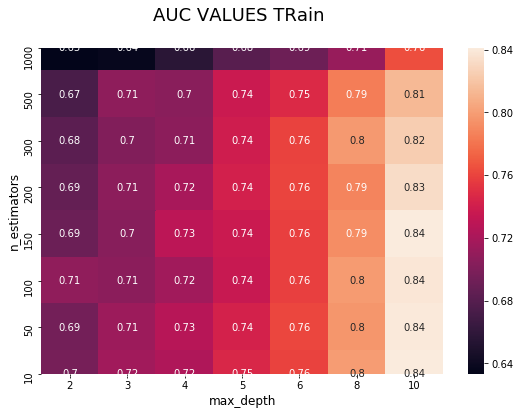

In [69]:
nn = np.asarray(result)
from pandas import DataFrame
import seaborn as sns
Index= [10, 50, 100, 150, 200, 300, 500, 1000]
Cols = [2, 3, 4, 5, 6, 8, 10]
df = DataFrame(data=nn.reshape(8,7), index=Index[::-1], columns=Cols)
plt.figure(figsize=(9, 6))
heatmap=sns.heatmap(df, annot=True)
plt.ylabel('n_estimators',size=12)
plt.xlabel('max_depth',size=12)
plt.title("AUC VALUES TRain \n",size=18)
plt.show()

### Heat Map For CV Data

In [70]:
n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000]
max_depth = [2, 3, 4, 5, 6, 8, 10]

In [71]:
result = []
for i in tqdm(n_estimators):
    for j in max_depth:
        RF = RandomForestClassifier(n_estimators = i ,max_depth = j ,class_weight='balanced')
        RF.fit(X_tr,y_train)
        y2_pred_proba=[]
        y2_pred_proba.extend(RF.predict_proba(X_cr)[:,1])
        result.append(roc_auc_score(y_cv,y2_pred_proba))

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:27<00:00, 55.53s/it]


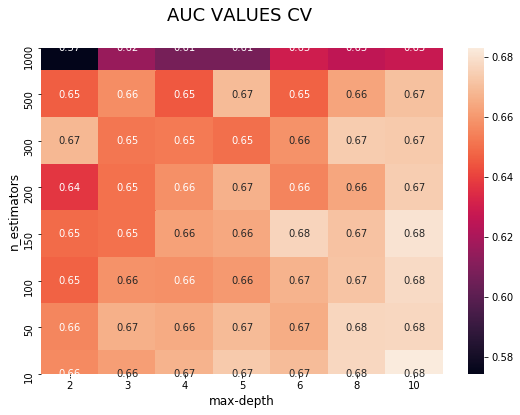

In [72]:
nn = np.asarray(result)
from pandas import DataFrame
import seaborn as sns
Index= [10, 50, 100, 150, 200, 300, 500, 1000]
Cols = [2, 3, 4, 5, 6, 8, 10]
df = DataFrame(data=nn.reshape(8,7), index=Index[::-1], columns=Cols)
plt.figure(figsize=(9, 6))
heatmap=sns.heatmap(df, annot=True)
plt.ylabel('n_estimators',size=12)
plt.xlabel('max-depth',size=12)
plt.title("AUC VALUES CV \n",size=18)
plt.show()

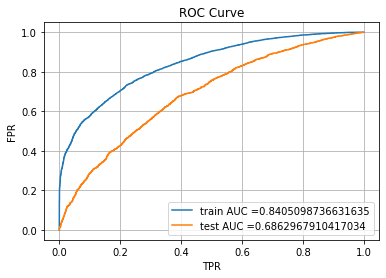

In [73]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#sklearn.metrics.roc_curve
from sklearn.metrics import roc_curve, auc

RF = RandomForestClassifier(n_estimators = 300  ,max_depth = 10  ,class_weight='balanced')
RF.fit(X_tr,y_train)
# roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
# not the predicted outputs

y_train_pred = RF.predict_proba(X_tr[:])[:,1]
y_test_pred    = RF.predict_proba(X_te[:])[:,1] 

train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_train_pred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_test_pred)
        
plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("TPR")
plt.ylabel("FPR")
plt.title("ROC Curve")
plt.grid()
plt.show()

### Computing a Confusion Matrix for train and test

In [74]:
# we are writing our own function for predict, with defined thresould
# we will pick a threshold that will give the least fpr
def find_best_threshold(threshould, fpr, tpr):
    t = threshould[np.argmax(tpr*(1-fpr))]
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    print("the maximum value of tpr*(1-fpr)", max(tpr*(1-fpr)), "for threshold", np.round(t,3))
    return t

def predict_with_best_t(proba, threshould):
    predictions = []
    for i in proba:
        if i>=threshould:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

the maximum value of tpr*(1-fpr) 0.5704494479902937 for threshold 0.504
Train confusion matrix
[[ 3537  1016]
 [ 6761 18686]]


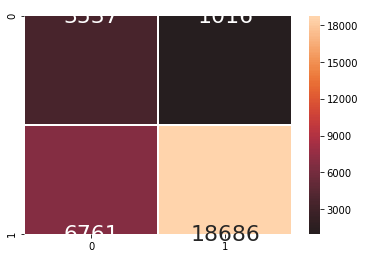

In [75]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
from sklearn.metrics import confusion_matrix
best_t = find_best_threshold(tr_thresholds, train_fpr, train_tpr)
print("Train confusion matrix")
print(confusion_matrix(y_train, predict_with_best_t(y_train_pred, best_t)))
x_matrix_train = confusion_matrix(y_train, predict_with_best_t(y_train_pred, best_t))
print("=="*62)
ax = sns.heatmap(x_matrix_train, annot=True, fmt="d",annot_kws={"size": 22}, center=0,linewidths=.5)

Test confusion matrix
[[ 852  655]
 [2586 5907]]


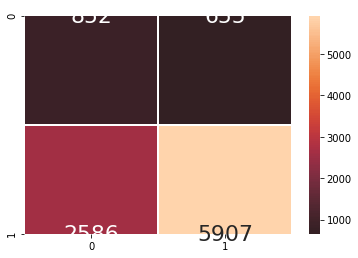

In [76]:
print("Test confusion matrix")
print(confusion_matrix(y_test, predict_with_best_t(y_test_pred, best_t)))
x_matrix_test = confusion_matrix(y_test, predict_with_best_t(y_test_pred, best_t))
print("=="*62)
ax = sns.heatmap(x_matrix_test, annot=True, fmt="d",annot_kws={"size": 22}, center=0,linewidths=.5)

### Set 2: categorical(instead of one hot encoding, try response coding: use probability values), numerical features + project_title(TFIDF)+ preprocessed_eassay (TFIDF)

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
print(X_train.shape, y_train.shape)
print(X_cv.shape, y_cv.shape)
print(X_test.shape, y_test.shape)

print("="*100)


vectorizer = TfidfVectorizer(min_df=10,max_features=5000,ngram_range=(1,2))
vectorizer.fit(X_train['preprocessed_essays'].values) # fit has to happen only on train data

# we use the fitted TfidfVectorizer to convert the text to vector
X_train_essay_tfidf = vectorizer.transform(X_train['preprocessed_essays'].values)
X_cv_essay_tfidf = vectorizer.transform(X_cv['preprocessed_essays'].values)
X_test_essay_tfidf = vectorizer.transform(X_test['preprocessed_essays'].values)

print("After  TFIDF Vectorizations")
print(X_train_essay_tfidf.shape, y_train.shape)
print(X_cv_essay_tfidf.shape, y_cv.shape)
print(X_test_essay_tfidf.shape, y_test.shape)
print("="*100)


(49039, 24) (30000,)
(24155, 24) (10000,)
(36051, 24) (10000,)
After  TFIDF Vectorizations
(49039, 5000) (30000,)
(24155, 5000) (10000,)
(36051, 5000) (10000,)


In [78]:

print(X_train.shape, y_train.shape)
print(X_cv.shape, y_cv.shape)
print(X_test.shape, y_test.shape)

print("="*100)


vectorizer = TfidfVectorizer(min_df=10)
vectorizer.fit(X_train['preprocessed_title'].values) # fit has to happen only on train data

# we use the fitted TfidfVectorizer to convert the text to vector
X_train_title_tfidf = vectorizer.transform(X_train['preprocessed_title'].values)
X_cv_title_tfidf = vectorizer.transform(X_cv['preprocessed_title'].values)
X_test_title_tfidf = vectorizer.transform(X_test['preprocessed_title'].values)

print("After vectorizations")
print(X_train_title_tfidf.shape, y_train.shape)
print(X_cv_title_tfidf.shape, y_cv.shape)
print(X_test_title_tfidf.shape, y_test.shape)
print("="*100)

(49039, 24) (30000,)
(24155, 24) (10000,)
(36051, 24) (10000,)
After vectorizations
(49039, 2093) (30000,)
(24155, 2093) (10000,)
(36051, 2093) (10000,)


In [79]:
# merge two sparse matrices: https://stackoverflow.com/a/19710648/4084039
from scipy.sparse import hstack
X_tr = hstack((X_train_clean_cat, X_train_clean_subcat,X_train_school,X_train_prefix_teacher,X_train_grade,X_train_teacher_prev_proj, X_train_price_norm, X_train_essay_tfidf, X_train_title_tfidf)).tocsr()
X_cr = hstack((X_cv_clean_cat, X_cv_clean_subcat,X_cv_school,X_cv_prefix_teacher,X_cv_grade,X_cv_teacher_prev_proj, X_cv_price_norm, X_cv_essay_tfidf, X_cv_title_tfidf)).tocsr()
X_te = hstack((X_test_clean_cat, X_test_clean_subcat,X_test_school,X_test_prefix_teacher,X_test_grade,X_test_teacher_prev_proj, X_test_price_norm, X_test_essay_tfidf, X_test_title_tfidf)).tocsr()

X_tr = X_tr[:30000,:]
X_cr = X_cr[:10000,:]
X_te = X_te[:10000,:]
y_train = y_train[:30000,]
y_cv    = y_cv[:10000,]
y_test  = y_test[:10000,]
print("Final Data matrix")
print(X_tr.shape, y_train.shape)
print(X_cr.shape, y_cv.shape)
print(X_te.shape, y_test.shape)
print("="*100)

Final Data matrix
(30000, 7105) (30000,)
(10000, 7105) (10000,)
(10000, 7105) (10000,)


###  Hyperparameters n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000], max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10]

### Heat Map For Train Data

In [80]:
n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000]
max_depth = [2, 3, 4, 5, 6, 8, 10]
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [81]:
result = []
for i in tqdm(n_estimators):
    for j in max_depth:
        RF = RandomForestClassifier(n_estimators = i ,max_depth = j ,class_weight='balanced')
        RF.fit(X_tr,y_train)
        y2_pred_proba=[]
        y2_pred_proba.extend(RF.predict_proba(X_tr)[:,1])
        result.append(roc_auc_score(y_train,y2_pred_proba))

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [12:20<00:00, 169.69s/it]


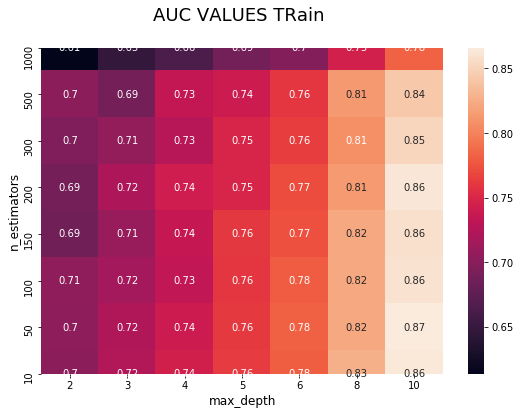

In [82]:
nn = np.asarray(result)
from pandas import DataFrame
import seaborn as sns
Index= [10, 50, 100, 150, 200, 300, 500, 1000]
Cols = [2, 3, 4, 5, 6, 8, 10]
df = DataFrame(data=nn.reshape(8,7), index=Index[::-1], columns=Cols)
plt.figure(figsize=(9, 6))
heatmap=sns.heatmap(df, annot=True)
plt.ylabel('n_estimators',size=12)
plt.xlabel('max_depth',size=12)
plt.title("AUC VALUES TRain \n",size=18)
plt.show()

### Heat Map For CV Data

In [83]:
n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000]
max_depth = [2, 3, 4, 5, 6, 8, 10]

In [84]:
result = []
for i in tqdm(n_estimators):
    for j in max_depth:
        RF = RandomForestClassifier(n_estimators = i ,max_depth = j ,class_weight='balanced')
        RF.fit(X_tr,y_train)
        y2_pred_proba=[]
        y2_pred_proba.extend(RF.predict_proba(X_cr)[:,1])
        result.append(roc_auc_score(y_cv,y2_pred_proba))

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:24<00:00, 93.41s/it]


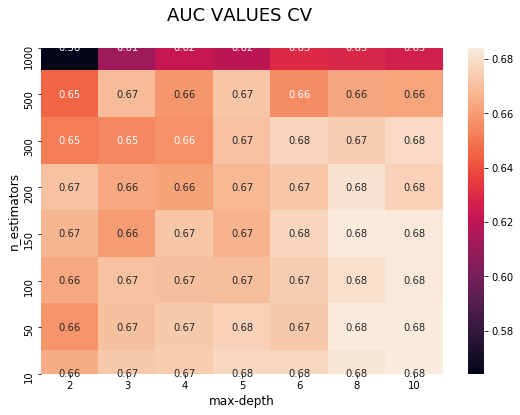

In [85]:
nn = np.asarray(result)
from pandas import DataFrame
import seaborn as sns
Index= [10, 50, 100, 150, 200, 300, 500, 1000]
Cols = [2, 3, 4, 5, 6, 8, 10]
df = DataFrame(data=nn.reshape(8,7), index=Index[::-1], columns=Cols)
plt.figure(figsize=(9, 6))
heatmap=sns.heatmap(df, annot=True)
plt.ylabel('n_estimators',size=12)
plt.xlabel('max-depth',size=12)
plt.title("AUC VALUES CV \n",size=18)
plt.show()

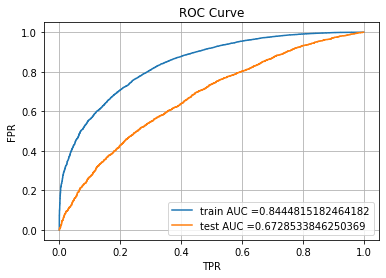

In [86]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#sklearn.metrics.roc_curve
from sklearn.metrics import roc_curve, auc

RF = RandomForestClassifier(n_estimators = 50  ,max_depth = 10  ,class_weight='balanced')
RF.fit(X_tr,y_train)
# roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
# not the predicted outputs

y_train_pred = RF.predict_proba(X_tr[:])[:,1]
y_test_pred    = RF.predict_proba(X_te[:])[:,1] 

train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_train_pred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_test_pred)
        
plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("TPR")
plt.ylabel("FPR")
plt.title("ROC Curve")
plt.grid()
plt.show()

### Computing a Confusion Matrix for train and test

In [87]:
# we are writing our own function for predict, with defined thresould
# we will pick a threshold that will give the least fpr
def find_best_threshold(threshould, fpr, tpr):
    t = threshould[np.argmax(tpr*(1-fpr))]
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    print("the maximum value of tpr*(1-fpr)", max(tpr*(1-fpr)), "for threshold", np.round(t,3))
    return t

def predict_with_best_t(proba, threshould):
    predictions = []
    for i in proba:
        if i>=threshould:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

the maximum value of tpr*(1-fpr) 0.5740703897165161 for threshold 0.506
Train confusion matrix
[[ 3435  1118]
 [ 6084 19363]]


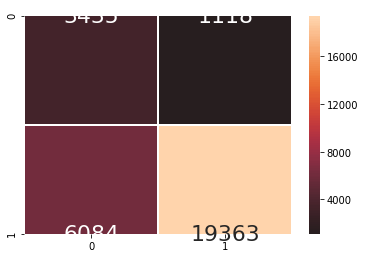

In [88]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
from sklearn.metrics import confusion_matrix
best_t = find_best_threshold(tr_thresholds, train_fpr, train_tpr)
print("Train confusion matrix")
print(confusion_matrix(y_train, predict_with_best_t(y_train_pred, best_t)))
x_matrix_train = confusion_matrix(y_train, predict_with_best_t(y_train_pred, best_t))
print("=="*62)
ax = sns.heatmap(x_matrix_train, annot=True, fmt="d",annot_kws={"size": 22}, center=0,linewidths=.5)

Test confusion matrix
[[ 791  716]
 [2453 6040]]


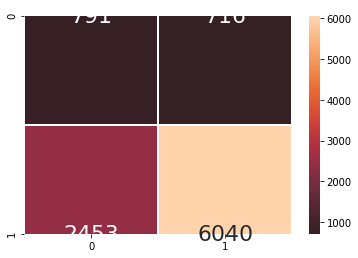

In [89]:
print("Test confusion matrix")
print(confusion_matrix(y_test, predict_with_best_t(y_test_pred, best_t)))
x_matrix_test = confusion_matrix(y_test, predict_with_best_t(y_test_pred, best_t))
print("=="*62)
ax = sns.heatmap(x_matrix_test, annot=True, fmt="d",annot_kws={"size": 22}, center=0,linewidths=.5)

####  Set 3: categorical(instead of one hot encoding, try response coding: use probability values), numerical features + project_title(AVG W2V)+ preprocessed_eassay (AVG W2V). Here for this set take 20K datapoints only.

In [90]:
# stronging variables into pickle files python: http://www.jessicayung.com/how-to-use-pickle-to-save-and-load-variables-in-python/
# make sure you have the glove_vectors file
with open('glove_vectors', 'rb') as f:
    model = pickle.load(f)
    glove_words =  set(model.keys())

In [91]:
# average Word2Vec
# compute average word2vec for each Essay.
avg_w2v_vectors_train_essays = []; # the avg-w2v for each Essay is stored in this list
for sentence in tqdm(X_train['preprocessed_essays']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    cnt_words =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if word in glove_words:
            vector += model[word]
            cnt_words += 1
    if cnt_words != 0:
        vector /= cnt_words
    avg_w2v_vectors_train_essays.append(vector)

print(len(avg_w2v_vectors_train_essays))
print(len(avg_w2v_vectors_train_essays[0]))

100%|██████████████████████████████████████████████████████████████████████████| 49039/49039 [00:12<00:00, 3860.35it/s]


49039
300


In [92]:
# average Word2Vec
# compute average word2vec for each review.
avg_w2v_vectors_cv_essays = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_cv['preprocessed_essays']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    cnt_words =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if word in glove_words:
            vector += model[word]
            cnt_words += 1
    if cnt_words != 0:
        vector /= cnt_words
    avg_w2v_vectors_cv_essays.append(vector)

print(len(avg_w2v_vectors_cv_essays))
print(len(avg_w2v_vectors_cv_essays[0]))

100%|██████████████████████████████████████████████████████████████████████████| 24155/24155 [00:06<00:00, 3863.59it/s]


24155
300


In [93]:
# average Word2Vec
# compute average word2vec for each review.
avg_w2v_vectors_test_essays = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_test['preprocessed_essays']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    cnt_words =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if word in glove_words:
            vector += model[word]
            cnt_words += 1
    if cnt_words != 0:
        vector /= cnt_words
    avg_w2v_vectors_test_essays.append(vector)

print(len(avg_w2v_vectors_test_essays))
print(len(avg_w2v_vectors_test_essays[0]))

100%|██████████████████████████████████████████████████████████████████████████| 36051/36051 [00:09<00:00, 3888.44it/s]


36051
300


In [94]:
# average Word2Vec
# compute average word2vec for each review.
avg_w2v_vectors_train_title = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_train['preprocessed_title']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    cnt_words =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if word in glove_words:
            vector += model[word]
            cnt_words += 1
    if cnt_words != 0:
        vector /= cnt_words
    avg_w2v_vectors_train_title.append(vector)

print(len(avg_w2v_vectors_train_title))
print(len(avg_w2v_vectors_train_title[0]))

100%|█████████████████████████████████████████████████████████████████████████| 49039/49039 [00:00<00:00, 70796.44it/s]


49039
300


In [95]:
# average Word2Vec
# compute average word2vec for each review.
avg_w2v_vectors_cv_title = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_cv['preprocessed_title']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    cnt_words =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if word in glove_words:
            vector += model[word]
            cnt_words += 1
    if cnt_words != 0:
        vector /= cnt_words
    avg_w2v_vectors_cv_title.append(vector)

print(len(avg_w2v_vectors_cv_title))
print(len(avg_w2v_vectors_cv_title[0]))

100%|█████████████████████████████████████████████████████████████████████████| 24155/24155 [00:00<00:00, 70402.59it/s]


24155
300


In [96]:
# average Word2Vec
# compute average word2vec for each review.
avg_w2v_vectors_test_title = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_test['preprocessed_title']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    cnt_words =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if word in glove_words:
            vector += model[word]
            cnt_words += 1
    if cnt_words != 0:
        vector /= cnt_words
    avg_w2v_vectors_test_title.append(vector)

print(len(avg_w2v_vectors_test_title))
print(len(avg_w2v_vectors_test_title[0]))


100%|█████████████████████████████████████████████████████████████████████████| 36051/36051 [00:00<00:00, 70034.25it/s]


36051
300


In [97]:
# merge two sparse matrices: https://stackoverflow.com/a/19710648/4084039
from scipy.sparse import hstack
X_tr = np.hstack((X_train_clean_cat, X_train_clean_subcat,X_train_school,X_train_prefix_teacher,X_train_grade,X_train_teacher_prev_proj, X_train_price_norm, avg_w2v_vectors_train_essays, avg_w2v_vectors_train_title))
X_cr = np.hstack((X_cv_clean_cat, X_cv_clean_subcat,X_cv_school,X_cv_prefix_teacher,X_cv_grade,X_cv_teacher_prev_proj, X_cv_price_norm, avg_w2v_vectors_cv_essays, avg_w2v_vectors_cv_title))
X_te = np.hstack((X_test_clean_cat, X_test_clean_subcat,X_test_school,X_test_prefix_teacher,X_test_grade,X_test_teacher_prev_proj, X_test_price_norm, avg_w2v_vectors_test_essays, avg_w2v_vectors_test_title))

X_tr = X_tr[:10000,:]
X_cr = X_cr[:5000,:]
X_te = X_te[:5000,:]
y_train = y_train[:10000,]
y_cv    = y_cv[:5000,]
y_test  = y_test[:5000,]
print("Final Data matrix")
print(X_tr.shape, y_train.shape)
print(X_cr.shape, y_cv.shape)
print(X_te.shape, y_test.shape)
print("="*100)

Final Data matrix
(10000, 612) (10000,)
(5000, 612) (5000,)
(5000, 612) (5000,)


###  Hyperparameters n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000], max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10]

### Heat Map For Train Data

In [98]:
n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000]
max_depth = [2, 3, 4, 5, 6, 8, 10]
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [99]:
result = []
for i in tqdm(n_estimators):
    for j in max_depth:
        RF = RandomForestClassifier(n_estimators = i ,max_depth = j ,class_weight='balanced')
        RF.fit(X_tr,y_train)
        y2_pred_proba=[]
        y2_pred_proba.extend(RF.predict_proba(X_tr)[:,1])
        result.append(roc_auc_score(y_train,y2_pred_proba))

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [22:18<00:00, 283.48s/it]


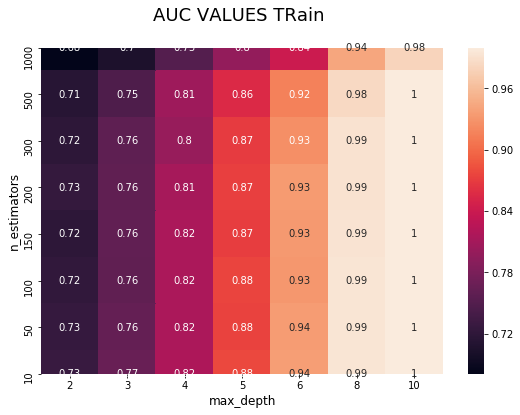

In [100]:
nn = np.asarray(result)
from pandas import DataFrame
import seaborn as sns
Index= [10, 50, 100, 150, 200, 300, 500, 1000]
Cols = [2, 3, 4, 5, 6, 8, 10]
df = DataFrame(data=nn.reshape(8,7), index=Index[::-1], columns=Cols)
plt.figure(figsize=(9, 6))
heatmap=sns.heatmap(df, annot=True)
plt.ylabel('n_estimators',size=12)
plt.xlabel('max_depth',size=12)
plt.title("AUC VALUES TRain \n",size=18)
plt.show()

### Heat Map For CV Data

In [101]:
n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000]
max_depth = [2, 3, 4, 5, 6, 8, 10]

In [102]:
result = []
for i in tqdm(n_estimators):
    for j in max_depth:
        RF = RandomForestClassifier(n_estimators = i ,max_depth = j ,class_weight='balanced')
        RF.fit(X_tr,y_train)
        y2_pred_proba=[]
        y2_pred_proba.extend(RF.predict_proba(X_cr)[:,1])
        result.append(roc_auc_score(y_cv,y2_pred_proba))

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [33:17<00:00, 480.39s/it]


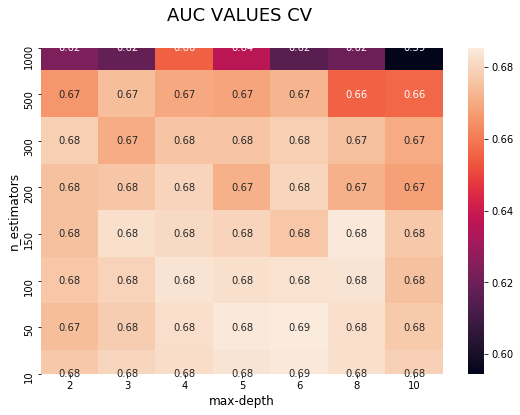

In [103]:
nn = np.asarray(result)
from pandas import DataFrame
import seaborn as sns
Index= [10, 50, 100, 150, 200, 300, 500, 1000]
Cols = [2, 3, 4, 5, 6, 8, 10]
df = DataFrame(data=nn.reshape(8,7), index=Index[::-1], columns=Cols)
plt.figure(figsize=(9, 6))
heatmap=sns.heatmap(df, annot=True)
plt.ylabel('n_estimators',size=12)
plt.xlabel('max-depth',size=12)
plt.title("AUC VALUES CV \n",size=18)
plt.show()

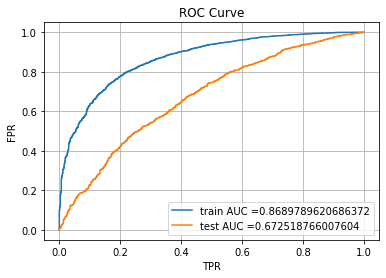

In [104]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#sklearn.metrics.roc_curve
from sklearn.metrics import roc_curve, auc

RF = RandomForestClassifier(n_estimators = 100  ,max_depth = 5  ,class_weight='balanced')
RF.fit(X_tr,y_train)
# roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
# not the predicted outputs

y_train_pred = RF.predict_proba(X_tr[:])[:,1]
y_test_pred    = RF.predict_proba(X_te[:])[:,1] 

train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_train_pred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_test_pred)
        
plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("TPR")
plt.ylabel("FPR")
plt.title("ROC Curve")
plt.grid()
plt.show()

### Computing a Confusion Matrix for train and test

the maximum value of tpr*(1-fpr) 0.6235335969100512 for threshold 0.511
Train confusion matrix
[[1190  321]
 [1768 6721]]


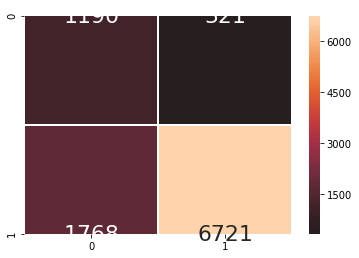

In [105]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
from sklearn.metrics import confusion_matrix
best_t = find_best_threshold(tr_thresholds, train_fpr, train_tpr)
print("Train confusion matrix")
print(confusion_matrix(y_train, predict_with_best_t(y_train_pred, best_t)))
x_matrix_train = confusion_matrix(y_train, predict_with_best_t(y_train_pred, best_t))
print("=="*62)
ax = sns.heatmap(x_matrix_train, annot=True, fmt="d",annot_kws={"size": 22}, center=0,linewidths=.5)    

Test confusion matrix
[[ 372  370]
 [1085 3173]]


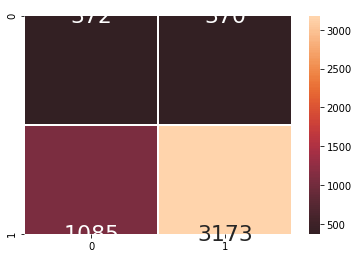

In [106]:
print("Test confusion matrix")
print(confusion_matrix(y_test, predict_with_best_t(y_test_pred, best_t)))
x_matrix_test = confusion_matrix(y_test, predict_with_best_t(y_test_pred, best_t))
print("=="*62)
ax = sns.heatmap(x_matrix_test, annot=True, fmt="d",annot_kws={"size": 22}, center=0,linewidths=.5)

#### Set 4: categorical(instead of one hot encoding, try response coding: use probability values), numerical features + project_title(TFIDF W2V)+ preprocessed_eassay (TFIDF W2V). Here for this set take 20K datapoints only.

In [107]:
# stronging variables into pickle files python: http://www.jessicayung.com/how-to-use-pickle-to-save-and-load-variables-in-python/
# make sure you have the glove_vectors file
with open('glove_vectors', 'rb') as f:
    model = pickle.load(f)
    glove_words =  set(model.keys())

In [108]:
# S = ["abc def pqr", "def def def abc", "pqr pqr def"]
tfidf_model = TfidfVectorizer()
tfidf_model.fit(X_train['preprocessed_essays'])
# we are converting a dictionary with word as a key, and the idf as a value
dictionary = dict(zip(tfidf_model.get_feature_names(), list(tfidf_model.idf_)))
tfidf_words = set(tfidf_model.get_feature_names())

In [109]:
# average tfidf-Word2Vec
# compute average word2vec for each review.
tfidf_w2v_vectors_train_essays = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_train['preprocessed_essays']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    tf_idf_weight =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] # getting the vector for each word
            # here we are multiplying idf value(dictionary[word]) and the tf value((sentence.count(word)/len(sentence.split())))
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) # getting the tfidf value for each word
            vector += (vec * tf_idf) # calculating tfidf weighted w2v
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    tfidf_w2v_vectors_train_essays.append(vector)

print(len(tfidf_w2v_vectors_train_essays))
print(len(tfidf_w2v_vectors_train_essays[0]))

100%|███████████████████████████████████████████████████████████████████████████| 49039/49039 [03:22<00:00, 242.34it/s]


49039
300


In [110]:
# # average tfidf-Word2Vec
# compute average word2vec for each review.
tfidf_w2v_vectors_cv_essays = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_cv['preprocessed_essays']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    tf_idf_weight =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] # getting the vector for each word
            # here we are multiplying idf value(dictionary[word]) and the tf value((sentence.count(word)/len(sentence.split())))
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) # getting the tfidf value for each word
            vector += (vec * tf_idf) # calculating tfidf weighted w2v
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    tfidf_w2v_vectors_cv_essays.append(vector)

print(len(tfidf_w2v_vectors_cv_essays))
print(len(tfidf_w2v_vectors_cv_essays[0]))

100%|███████████████████████████████████████████████████████████████████████████| 24155/24155 [01:39<00:00, 243.14it/s]


24155
300


In [111]:
# # average tfidf-Word2Vec
# compute average word2vec for each review.
tfidf_w2v_vectors_test_essays = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_test['preprocessed_essays']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    tf_idf_weight =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] # getting the vector for each word
            # here we are multiplying idf value(dictionary[word]) and the tf value((sentence.count(word)/len(sentence.split())))
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) # getting the tfidf value for each word
            vector += (vec * tf_idf) # calculating tfidf weighted w2v
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    tfidf_w2v_vectors_test_essays.append(vector)

print(len(tfidf_w2v_vectors_test_essays))
print(len(tfidf_w2v_vectors_test_essays[0]))

100%|███████████████████████████████████████████████████████████████████████████| 36051/36051 [02:26<00:00, 245.52it/s]


36051
300


In [112]:
# S = ["abc def pqr", "def def def abc", "pqr pqr def"]
tfidf_model = TfidfVectorizer()
tfidf_model.fit(X_train['preprocessed_title'])
# we are converting a dictionary with word as a key, and the idf as a value
dictionary = dict(zip(tfidf_model.get_feature_names(), list(tfidf_model.idf_)))
tfidf_words = set(tfidf_model.get_feature_names())

In [113]:
# # average tfidf-Word2Vec
# compute average word2vec for each review.
tfidf_w2v_vectors_train_title = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_train['preprocessed_title']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    tf_idf_weight =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] # getting the vector for each word
            # here we are multiplying idf value(dictionary[word]) and the tf value((sentence.count(word)/len(sentence.split())))
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) # getting the tfidf value for each word
            vector += (vec * tf_idf) # calculating tfidf weighted w2v
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    tfidf_w2v_vectors_train_title.append(vector)

print(len(tfidf_w2v_vectors_train_title))
print(len(tfidf_w2v_vectors_train_title[0]))

100%|█████████████████████████████████████████████████████████████████████████| 49039/49039 [00:03<00:00, 15025.57it/s]


49039
300


In [114]:
# # average tfidf-Word2Vec
# compute average word2vec for each review.
tfidf_w2v_vectors_cv_title = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_cv['preprocessed_title']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    tf_idf_weight =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] # getting the vector for each word
            # here we are multiplying idf value(dictionary[word]) and the tf value((sentence.count(word)/len(sentence.split())))
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) # getting the tfidf value for each word
            vector += (vec * tf_idf) # calculating tfidf weighted w2v
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    tfidf_w2v_vectors_cv_title.append(vector)

print(len(tfidf_w2v_vectors_cv_title))
print(len(tfidf_w2v_vectors_cv_title[0]))

100%|█████████████████████████████████████████████████████████████████████████| 24155/24155 [00:01<00:00, 15842.86it/s]


24155
300


In [115]:
# # average tfidf-Word2Vec
# compute average word2vec for each review.
tfidf_w2v_vectors_test_title = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(X_test['preprocessed_title']): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    tf_idf_weight =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] # getting the vector for each word
            # here we are multiplying idf value(dictionary[word]) and the tf value((sentence.count(word)/len(sentence.split())))
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) # getting the tfidf value for each word
            vector += (vec * tf_idf) # calculating tfidf weighted w2v
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    tfidf_w2v_vectors_test_title.append(vector)

print(len(tfidf_w2v_vectors_test_title))
print(len(tfidf_w2v_vectors_test_title[0]))

100%|█████████████████████████████████████████████████████████████████████████| 36051/36051 [00:02<00:00, 15386.69it/s]


36051
300


In [116]:
# merge two sparse matrices: https://stackoverflow.com/a/19710648/4084039
from scipy.sparse import hstack
X_tr = np.hstack((X_train_clean_cat, X_train_clean_subcat,X_train_school,X_train_prefix_teacher,X_train_grade,X_train_teacher_prev_proj, X_train_price_norm, tfidf_w2v_vectors_train_essays, tfidf_w2v_vectors_train_title))
X_cr = np.hstack((X_cv_clean_cat, X_cv_clean_subcat,X_cv_school,X_cv_prefix_teacher,X_cv_grade,X_cv_teacher_prev_proj, X_cv_price_norm, tfidf_w2v_vectors_cv_essays, tfidf_w2v_vectors_cv_title))
X_te = np.hstack((X_test_clean_cat, X_test_clean_subcat,X_test_school,X_test_prefix_teacher,X_test_grade,X_test_teacher_prev_proj, X_test_price_norm, tfidf_w2v_vectors_test_essays, tfidf_w2v_vectors_test_title))

X_tr = X_tr[:10000,:]
X_cr = X_cr[:5000,:]
X_te = X_te[:5000,:]
y_train = y_train[:10000,]
y_cv    = y_cv[:5000,]
y_test  = y_test[:5000,]
print("Final Data matrix")
print(X_tr.shape, y_train.shape)
print(X_cr.shape, y_cv.shape)
print(X_te.shape, y_test.shape)
print("="*100)

Final Data matrix
(10000, 612) (10000,)
(5000, 612) (5000,)
(5000, 612) (5000,)


###  Hyperparameters n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000], max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10]

### Heat Map For Train Data

In [117]:
n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000]
max_depth = [2, 3, 4, 5, 6, 8, 10]
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [118]:
result = []
for i in tqdm(n_estimators):
    for j in max_depth:
        RF = RandomForestClassifier(n_estimators = i ,max_depth = j ,class_weight='balanced')
        RF.fit(X_tr,y_train)
        y2_pred_proba=[]
        y2_pred_proba.extend(RF.predict_proba(X_tr)[:,1])
        result.append(roc_auc_score(y_train,y2_pred_proba))

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [49:02<00:00, 623.77s/it]


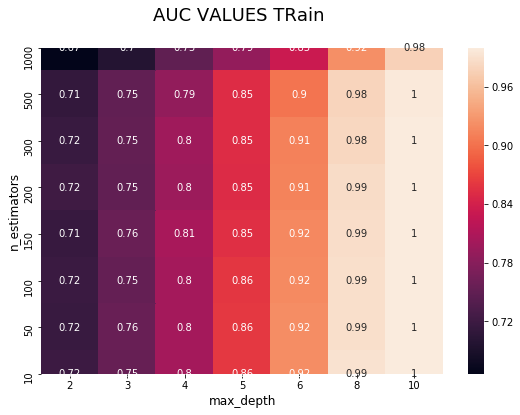

In [119]:
nn = np.asarray(result)
from pandas import DataFrame
import seaborn as sns
Index= [10, 50, 100, 150, 200, 300, 500, 1000]
Cols = [2, 3, 4, 5, 6, 8, 10]
df = DataFrame(data=nn.reshape(8,7), index=Index[::-1], columns=Cols)
plt.figure(figsize=(9, 6))
heatmap=sns.heatmap(df, annot=True)
plt.ylabel('n_estimators',size=12)
plt.xlabel('max_depth',size=12)
plt.title("AUC VALUES TRain \n",size=18)
plt.show()

### Heat Map For CV Data

In [120]:
n_estimators = [10, 50, 100, 150, 200, 300, 500, 1000]
max_depth = [2, 3, 4, 5, 6, 8, 10]

In [121]:
result = []
for i in tqdm(n_estimators):
    for j in max_depth:
        RF = RandomForestClassifier(n_estimators = i ,max_depth = j ,class_weight='balanced')
        RF.fit(X_tr,y_train)
        y2_pred_proba=[]
        y2_pred_proba.extend(RF.predict_proba(X_cr)[:,1])
        result.append(roc_auc_score(y_cv,y2_pred_proba))

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [48:44<00:00, 619.03s/it]


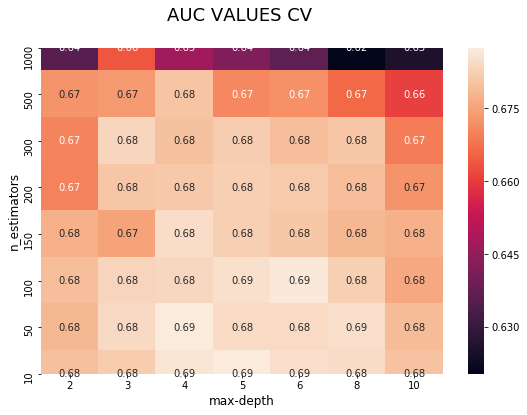

In [122]:
nn = np.asarray(result)
from pandas import DataFrame
import seaborn as sns
Index= [10, 50, 100, 150, 200, 300, 500, 1000]
Cols = [2, 3, 4, 5, 6, 8, 10]
df = DataFrame(data=nn.reshape(8,7), index=Index[::-1], columns=Cols)
plt.figure(figsize=(9, 6))
heatmap=sns.heatmap(df, annot=True)
plt.ylabel('n_estimators',size=12)
plt.xlabel('max-depth',size=12)
plt.title("AUC VALUES CV \n",size=18)
plt.show()

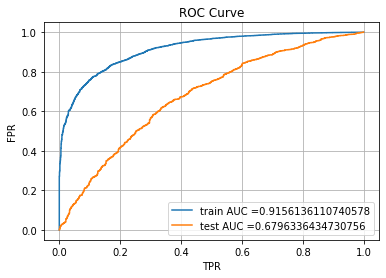

In [126]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#sklearn.metrics.roc_curve
from sklearn.metrics import roc_curve, auc

RF = RandomForestClassifier(n_estimators = 200  ,max_depth = 6  ,class_weight='balanced')
RF.fit(X_tr,y_train)
# roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
# not the predicted outputs

y_train_pred = RF.predict_proba(X_tr[:])[:,1]
y_test_pred    = RF.predict_proba(X_te[:])[:,1] 

train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_train_pred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_test_pred)
        
plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("TPR")
plt.ylabel("FPR")
plt.title("ROC Curve")
plt.grid()
plt.show()

### Computing a Confusion Matrix for train and test

the maximum value of tpr*(1-fpr) 0.9142506138866672 for threshold 0.505
Train confusion matrix
[[1451   60]
 [ 407 8082]]


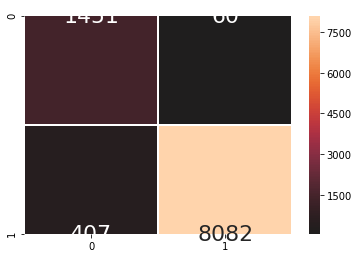

In [124]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
from sklearn.metrics import confusion_matrix
best_t = find_best_threshold(tr_thresholds, train_fpr, train_tpr)
print("Train confusion matrix")
print(confusion_matrix(y_train, predict_with_best_t(y_train_pred, best_t)))
x_matrix_train = confusion_matrix(y_train, predict_with_best_t(y_train_pred, best_t))
print("=="*62)
ax = sns.heatmap(x_matrix_train, annot=True, fmt="d",annot_kws={"size": 22}, center=0,linewidths=.5)

Test confusion matrix
[[ 183  559]
 [ 363 3895]]


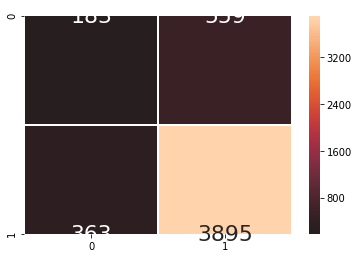

In [125]:
print("Test confusion matrix")
print(confusion_matrix(y_test, predict_with_best_t(y_test_pred, best_t)))
x_matrix_test = confusion_matrix(y_test, predict_with_best_t(y_test_pred, best_t))
print("=="*62)
ax = sns.heatmap(x_matrix_test, annot=True, fmt="d",annot_kws={"size": 22}, center=0,linewidths=.5)

In [128]:
# http://zetcode.com/python/prettytable/
from prettytable import PrettyTable
x = PrettyTable()
x.field_names = ["Vectoriser","Model" ,"Hyper Parameter-max-Depth","Hyper n-estimator","Train_AUC","Test_AUC"]
x.add_row(["BOW", "Brute",10,300,0.85,0.694 ])
x.add_row(["TFIDF","Brute" ,10,50,0.84,0.672])
x.add_row(["AVGW2V","Brute" ,5,100, 0.86,0.661])
x.add_row(["TFIDF-W2V","Brute" ,5,2, 0.91,0.672])
print(x)

+------------+-------+---------------------------+-------------------+-----------+----------+
| Vectoriser | Model | Hyper Parameter-max-Depth | Hyper n-estimator | Train_AUC | Test_AUC |
+------------+-------+---------------------------+-------------------+-----------+----------+
|    BOW     | Brute |             10            |        300        |    0.85   |  0.694   |
|   TFIDF    | Brute |             10            |         50        |    0.84   |  0.672   |
|   AVGW2V   | Brute |             5             |        100        |    0.86   |  0.661   |
| TFIDF-W2V  | Brute |             5             |         2         |    0.91   |  0.672   |
+------------+-------+---------------------------+-------------------+-----------+----------+
